# Tracking Runs with TensorBoard

This notebook adds exactly one workflow tool: **TensorBoard**, via PyTorch's native `SummaryWriter`.

The point is not to outsource the training loop. The point is to leave a useful trail behind each experiment:

- hyperparameters
- train and validation curves
- timing
- saved checkpoints

A notebook that cannot explain what changed between runs becomes hard to trust very quickly.


In [1]:
import shutil
import time
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.tensorboard import SummaryWriter

torch.manual_seed(11)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log_root = Path('runs_native')
log_root.mkdir(exist_ok=True)
print(f'Using device: {device}')


Using device: cuda


In [2]:
n_samples = 4000
n_features = 20

X = torch.randn(n_samples, n_features)
true_w = torch.randn(n_features, 1)
scores = X @ true_w + 0.3 * torch.randn(n_samples, 1)
y = (scores[:, 0] > 0.0).long()

dataset = TensorDataset(X, y)
train_set, val_set = random_split(dataset, [3200, 800], generator=torch.Generator().manual_seed(0))

def make_loaders(batch_size=128):
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, pin_memory=torch.cuda.is_available())
    return train_loader, val_loader


class TabularNet(nn.Module):
    def __init__(self, width=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, width),
            nn.ReLU(),
            nn.Linear(width, width),
            nn.ReLU(),
            nn.Linear(width, 2),
        )

    def forward(self, x):
        return self.net(x)


## Minimal Logging Utilities

A useful experiment directory should answer two questions later:

1. What configuration produced this run?
2. How did the metrics evolve while it trained?


In [3]:
def evaluate(model, loader):
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_examples += xb.size(0)
    return total_loss / total_examples, total_correct / total_examples


def train_with_tensorboard(run_name, *, lr, batch_size=128, epochs=8, width=64):
    run_dir = log_root / run_name
    if run_dir.exists():
        shutil.rmtree(run_dir)
    writer = SummaryWriter(log_dir=run_dir)

    train_loader, val_loader = make_loaders(batch_size=batch_size)
    model = TabularNet(width=width).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    writer.add_text('config', f'lr={lr}, batch_size={batch_size}, width={width}, epochs={epochs}')

    history = []
    global_step = 0
    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()
        model.train()
        total_train_loss = 0.0
        total_examples = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            batch_size_now = xb.size(0)
            total_train_loss += loss.item() * batch_size_now
            total_examples += batch_size_now
            writer.add_scalar('train/batch_loss', loss.item(), global_step)
            global_step += 1

        train_loss = total_train_loss / total_examples
        val_loss, val_acc = evaluate(model, val_loader)
        current_lr = optimizer.param_groups[0]['lr']
        epoch_seconds = time.perf_counter() - epoch_start

        writer.add_scalar('train/epoch_loss', train_loss, epoch)
        writer.add_scalar('validation/loss', val_loss, epoch)
        writer.add_scalar('validation/accuracy', val_acc, epoch)
        writer.add_scalar('optimizer/learning_rate', current_lr, epoch)
        writer.add_scalar('system/epoch_seconds', epoch_seconds, epoch)

        history.append({
            'run_name': run_name,
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_accuracy': val_acc,
            'epoch_seconds': epoch_seconds,
            'lr': lr,
            'batch_size': batch_size,
            'width': width,
        })

    checkpoint_path = run_dir / 'model.pt'
    torch.save({'model_state': model.state_dict(), 'run_name': run_name}, checkpoint_path)
    writer.add_text('artifacts', f'checkpoint={checkpoint_path}')
    writer.close()
    return history


## Experiment Grid: Batch Size and Model Width

Instead of comparing only two learning rates, we can treat TensorBoard as a lightweight experiment board. Here we keep the learning rate fixed and vary two other knobs that matter in practice:

- `batch_size`, which changes optimization noise and hardware utilization
- `width`, which changes model capacity

This is still a tiny sweep, but it already produces a much more realistic run directory.


In [5]:
experiment_grid = [
    {'batch_size': 64, 'width': 32},
    {'batch_size': 64, 'width': 128},
    {'batch_size': 256, 'width': 32},
    {'batch_size': 256, 'width': 128},
]

all_rows = []
for cfg in experiment_grid:
    run_name = f"bs_{cfg['batch_size']}_width_{cfg['width']}"
    all_rows.extend(
        train_with_tensorboard(
            run_name,
            lr=1e-3,
            batch_size=cfg['batch_size'],
            width=cfg['width'],
            epochs=20,
        )
    )

history = pd.DataFrame(all_rows)
history.head()


,run_name,epoch,train_loss,val_loss,val_accuracy,epoch_seconds,lr,batch_size,width
0,bs_64_width_32,1,0.631956,0.548579,0.81375,0.087464,0.001,64,32
1,bs_64_width_32,2,0.398624,0.260653,0.92750,0.084936,0.001,64,32
2,bs_64_width_32,3,0.188104,0.158628,0.94375,0.093261,0.001,64,32
3,bs_64_width_32,4,0.120706,0.127247,0.95500,0.082087,0.001,64,32
4,bs_64_width_32,5,0.091743,0.110922,0.95500,0.082084,0.001,64,32


,run_name,batch_size,width,val_loss,val_accuracy,epoch_seconds
19,bs_64_width_32,64,32,0.078448,0.96875,0.080695
39,bs_64_width_128,64,128,0.086266,0.97125,0.076922
59,bs_256_width_32,256,32,0.093473,0.95750,0.031719
79,bs_256_width_128,256,128,0.088269,0.96500,0.031511


batch_size,64,256
width,,
32,0.96875,0.9575
128,0.97125,0.9650


<Axes: xlabel='epoch'>

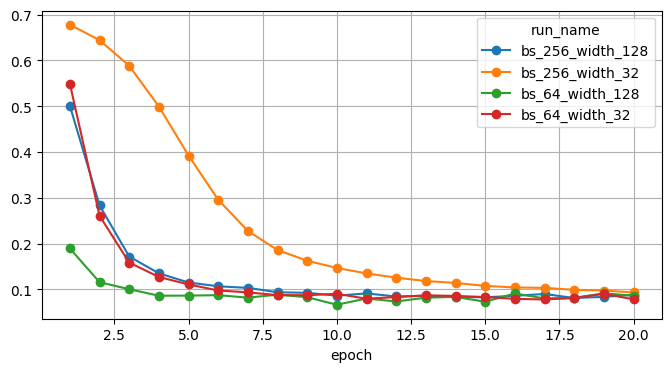

In [6]:
final_epoch = history.sort_values('epoch').groupby('run_name').tail(1).sort_values(['batch_size', 'width'])
display(final_epoch[['run_name', 'batch_size', 'width', 'val_loss', 'val_accuracy', 'epoch_seconds']])

display(final_epoch.pivot(index='width', columns='batch_size', values='val_accuracy'))

history.pivot(index='epoch', columns='run_name', values='val_loss').plot(figsize=(8, 4), marker='o', grid=True)


To launch TensorBoard from this directory, run one of these commands in a terminal:

```bash
.venv/bin/tensorboard --logdir notebooks/other_stuff_you_should_know/runs_native
```

or, from inside Jupyter:

```python
%load_ext tensorboard
%tensorboard --logdir notebooks/other_stuff_you_should_know/runs_native
```


In [7]:
sorted(str(path.relative_to(log_root)) for path in log_root.rglob('*'))[:20]


['bs_256_width_128',
 'bs_256_width_128/events.out.tfevents.1777484182.ocotillo.has.arizona.edu.612846.7',
 'bs_256_width_128/model.pt',
 'bs_256_width_32',
 'bs_256_width_32/events.out.tfevents.1777484182.ocotillo.has.arizona.edu.612846.6',
 'bs_256_width_32/model.pt',
 'bs_64_width_128',
 'bs_64_width_128/events.out.tfevents.1777484180.ocotillo.has.arizona.edu.612846.5',
 'bs_64_width_128/model.pt',
 'bs_64_width_32',
 'bs_64_width_32/events.out.tfevents.1777484178.ocotillo.has.arizona.edu.612846.4',
 'bs_64_width_32/model.pt',
 'lr_1e-3',
 'lr_1e-3/events.out.tfevents.1777478682.stubby.local.8747.0',
 'lr_1e-3/model.pt',
 'lr_3e-4',
 'lr_3e-4/events.out.tfevents.1777478682.stubby.local.8747.1',
 'lr_3e-4/model.pt']

**Minimum viable experiment workflow**

1. Put each run in its own directory.
2. Save the configuration with the metrics.
3. Log both batch-level and epoch-level information when it is cheap enough.
4. Save a checkpoint that lets you reload the exact trained weights later.

This is intentionally lightweight, but it already removes much of the confusion that shows up when experiments start to branch.
